In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import pandas as pd
filename = 'pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
dataframe = pd.read_csv(filename, names=names)
array = dataframe.values
X = array[:,0:8]
Y = array[:,8]

In [3]:
dataframe.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size = 0.3, random_state = 42)

In [5]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((537, 8), (537,), (231, 8), (231,))

###Grid Search CV

In [6]:
#Polynomial kernal
from sklearn.model_selection import GridSearchCV

# Define the pipeline for the Polynomial Kernel SVM
poly_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="poly", gamma="scale")) # gamma='scale' as default, but we'll tune it
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__degree': [2, 3, 4, 5],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

# Instantiate GridSearchCV
# Using 5-fold cross-validation
grid_search = GridSearchCV(poly_pipeline, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Evaluate the best model on the test set
best_poly_model = grid_search.best_estimator_
y_test_pred_tuned = best_poly_model.predict(X_test)
tuned_test_acc = accuracy_score(y_test, y_test_pred_tuned)

print(f"Test accuracy with tuned Polynomial Kernel: {tuned_test_acc:.3f}")
print("\nClassification report for tuned Polynomial Kernel:\n")
print(classification_report(y_test, y_test_pred_tuned))
print("Confusion matrix for tuned Polynomial Kernel:")
print(confusion_matrix(y_test, y_test_pred_tuned))

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best parameters found:  {'svm__C': 10, 'svm__degree': 3, 'svm__gamma': 'scale'}
Best cross-validation accuracy:  0.7466943579093112
Test accuracy with tuned Polynomial Kernel: 0.736

Classification report for tuned Polynomial Kernel:

              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81       151
         1.0       0.65      0.53      0.58        80

    accuracy                           0.74       231
   macro avg       0.71      0.69      0.69       231
weighted avg       0.73      0.74      0.73       231

Confusion matrix for tuned Polynomial Kernel:
[[128  23]
 [ 38  42]]


In [7]:
#RBF kernal
from sklearn.model_selection import GridSearchCV

# Define the pipeline for the RBF Kernel SVM
rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", gamma="scale")) # gamma='scale' as default, but we'll tune it
])

# Define the parameter grid for GridSearchCV for RBF kernel
param_grid_rbf = {
    'svm__C': [0.1, 1, 10, 100, 1000],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

# Instantiate GridSearchCV for RBF
# Using 5-fold cross-validation
grid_search_rbf = GridSearchCV(rbf_pipeline, param_grid_rbf, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_rbf.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for RBF Kernel: ", grid_search_rbf.best_params_)
print("Best cross-validation accuracy for RBF Kernel: ", grid_search_rbf.best_score_)

# Evaluate the best RBF model on the test set
best_rbf_model = grid_search_rbf.best_estimator_
y_test_pred_rbf_tuned = best_rbf_model.predict(X_test)
tuned_rbf_test_acc = accuracy_score(y_test, y_test_pred_rbf_tuned)

print(f"Test accuracy with tuned RBF Kernel: {tuned_rbf_test_acc:.3f}")
print("\nClassification report for tuned RBF Kernel:\n")
print(classification_report(y_test, y_test_pred_rbf_tuned))
print("Confusion matrix for tuned RBF Kernel:")
print(confusion_matrix(y_test, y_test_pred_rbf_tuned))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found for RBF Kernel:  {'svm__C': 10, 'svm__gamma': 0.001}
Best cross-validation accuracy for RBF Kernel:  0.7857909311180339
Test accuracy with tuned RBF Kernel: 0.758

Classification report for tuned RBF Kernel:

              precision    recall  f1-score   support

         0.0       0.80      0.85      0.82       151
         1.0       0.67      0.59      0.63        80

    accuracy                           0.76       231
   macro avg       0.73      0.72      0.72       231
weighted avg       0.75      0.76      0.75       231

Confusion matrix for tuned RBF Kernel:
[[128  23]
 [ 33  47]]


In [8]:
#Linear kernal
from sklearn.model_selection import GridSearchCV

# Define the pipeline for the Linear Kernel SVM
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

# Define the parameter grid for GridSearchCV for Linear kernel
param_grid_linear = {
    'svm__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Instantiate GridSearchCV for Linear Kernel
# Using 5-fold cross-validation
grid_search_linear = GridSearchCV(linear_pipeline, param_grid_linear, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_linear.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found for Linear Kernel: ", grid_search_linear.best_params_)
print("Best cross-validation accuracy for Linear Kernel: ", grid_search_linear.best_score_)

# Evaluate the best Linear model on the test set
best_linear_model = grid_search_linear.best_estimator_
y_test_pred_linear_tuned = best_linear_model.predict(X_test)
tuned_linear_test_acc = accuracy_score(y_test, y_test_pred_linear_tuned)

print(f"Test accuracy with tuned Linear Kernel: {tuned_linear_test_acc:.3f}")
print("\nClassification report for tuned Linear Kernel:\n")
print(classification_report(y_test, y_test_pred_linear_tuned))
print("Confusion matrix for tuned Linear Kernel:")
print(confusion_matrix(y_test, y_test_pred_linear_tuned))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters found for Linear Kernel:  {'svm__C': 1}
Best cross-validation accuracy for Linear Kernel:  0.7839217722395293
Test accuracy with tuned Linear Kernel: 0.749

Classification report for tuned Linear Kernel:

              precision    recall  f1-score   support

         0.0       0.80      0.81      0.81       151
         1.0       0.64      0.62      0.63        80

    accuracy                           0.75       231
   macro avg       0.72      0.72      0.72       231
weighted avg       0.75      0.75      0.75       231

Confusion matrix for tuned Linear Kernel:
[[123  28]
 [ 30  50]]


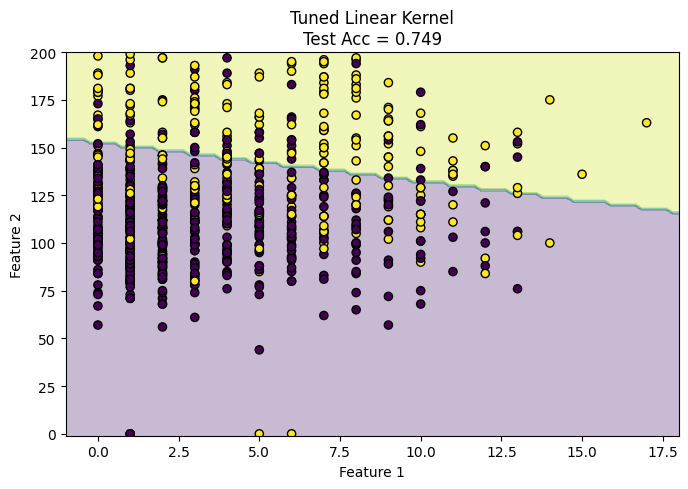

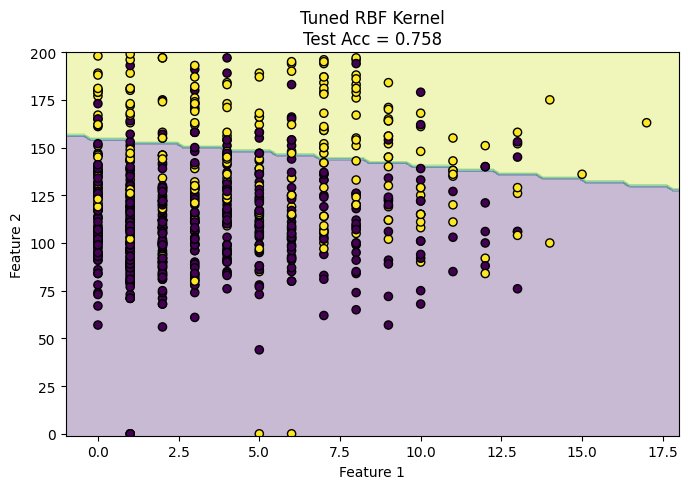

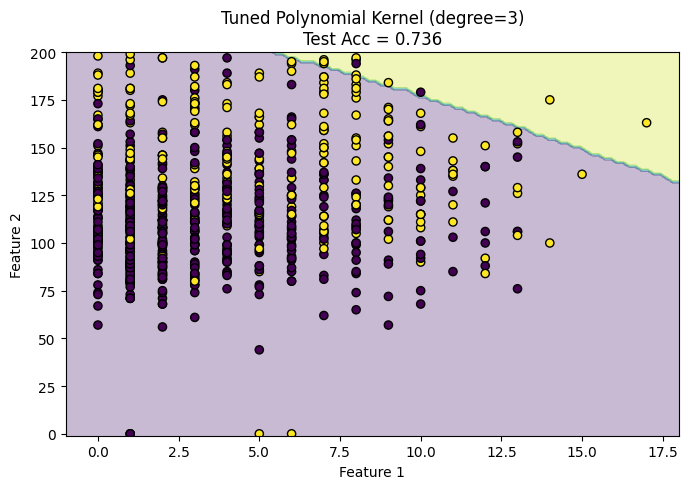

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os # Import os module to create directory

def plot_decision_boundary(model, X_plot, y_plot, title, feature_x_idx=0, feature_y_idx=1, save_path=None):
    # Ensure X_train is accessible for calculating means for other features
    global X_train
    if 'X_train' not in globals():
        raise NameError("X_train must be available in global scope for plotting decision boundaries of multi-feature models.")

    x_min, x_max = X_plot[:, feature_x_idx].min() - 1.0, X_plot[:, feature_x_idx].max() + 1.0
    y_min, y_max = X_plot[:, feature_y_idx].min() - 1.0, X_plot[:, feature_y_idx].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    # Create a 2D grid of the selected features
    grid_2d = np.c_[xx.ravel(), yy.ravel()]

    # Create a full 8-feature grid where the selected features vary,
    # and other features are held constant at their mean from the original X_train
    X_train_mean_val = X_train.mean(axis=0) # Mean of unscaled training data

    # Tile the mean values to create a base for the full grid
    grid_full = np.tile(X_train_mean_val, (grid_2d.shape[0], 1))

    # Insert the varying feature values into the full grid
    grid_full[:, feature_x_idx] = grid_2d[:, 0]
    grid_full[:, feature_y_idx] = grid_2d[:, 1]

    # Predict Z values using the full grid
    Z = model.predict(grid_full)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_plot[:, feature_x_idx], X_plot[:, feature_y_idx], c=y_plot, edgecolors="k", s=35)
    plt.title(title)
    plt.xlabel(f"Feature {feature_x_idx + 1}") # Using 1-based indexing for labels
    plt.ylabel(f"Feature {feature_y_idx + 1}") # Using 1-based indexing for labels
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

tuned_models_for_plotting = {
    "Tuned Linear Kernel": best_linear_model,
    "Tuned RBF Kernel": best_rbf_model,
    "Tuned Polynomial Kernel (degree=3)": best_poly_model
}

# Create a directory to save plots if it doesn't exist
save_dir = "plots"
os.makedirs(save_dir, exist_ok=True)

for name, model in tuned_models_for_plotting.items():
    # For simplicity, we'll use the test accuracy obtained directly from the grid search evaluation.
    if name == "Tuned Linear Kernel":
        current_test_acc = tuned_linear_test_acc
    elif name == "Tuned RBF Kernel":
        current_test_acc = tuned_rbf_test_acc
    elif name == "Tuned Polynomial Kernel (degree=3)":
        current_test_acc = tuned_test_acc # This is from the first GridSearchCV

    title = (
        f"{name}\n"
        f"Test Acc = {current_test_acc:.3f}"
    )
    # Construct filename for saving
    filename = os.path.join(save_dir, f"{name.replace(' ', '_').replace('(', '').replace(')', '')}_decision_boundary.png")
    # Plotting decision boundary for the first two features (indices 0 and 1)
    plot_decision_boundary(model, X, Y, title, feature_x_idx=0, feature_y_idx=1, save_path=filename)

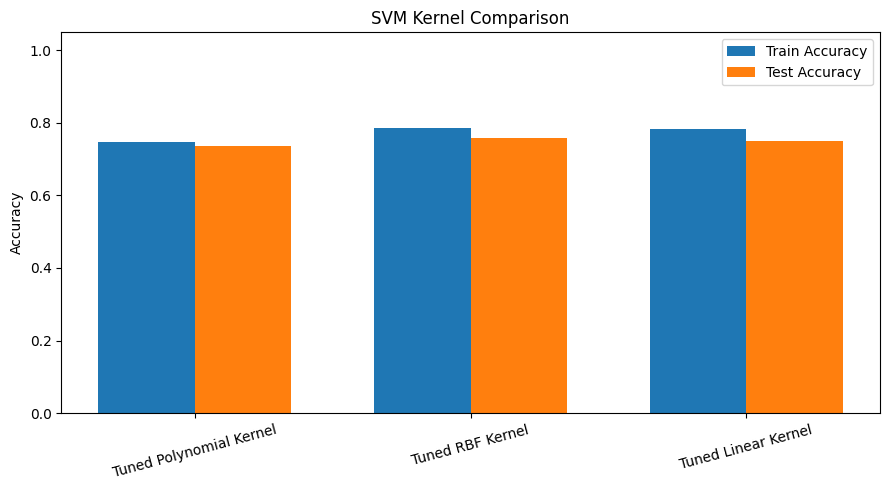

In [10]:
# -------------------------------
# compare all accuracies in one chart
# -------------------------------

# Re-create results dictionary for tuned models
results = {
    "Tuned Polynomial Kernel": {
        "train_acc": grid_search.best_score_, # Using best cross-validation accuracy as 'train_acc' for tuned model
        "test_acc": tuned_test_acc
    },
    "Tuned RBF Kernel": {
        "train_acc": grid_search_rbf.best_score_, # Using best cross-validation accuracy as 'train_acc' for tuned model
        "test_acc": tuned_rbf_test_acc
    },
    "Tuned Linear Kernel": {
        "train_acc": grid_search_linear.best_score_, # Using best cross-validation accuracy as 'train_acc' for tuned model
        "test_acc": tuned_linear_test_acc
    }
}

model_names = list(results.keys())
train_scores = [results[name]["train_acc"] for name in model_names]
test_scores = [results[name]["test_acc"] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, train_scores, width, label="Train Accuracy")
plt.bar(x + width/2, test_scores, width, label="Test Accuracy")
plt.xticks(x, model_names, rotation=15)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison")
plt.legend()
plt.tight_layout()

# Create a directory to save plots if it doesn't exist
save_dir = "plots"
os.makedirs(save_dir, exist_ok=True)

# Save the figure
plt.savefig(os.path.join(save_dir, "svm_kernel_comparison.png"))

plt.show()